# Experiment 1: Developmental profiles across the task battery

Four ordered profiles are run across a fully crossed 27-task battery of movement
distance, required rotation and object aspect ratio.

In [1]:
import json
from pathlib import Path

import numpy as np
import math

import analysis
import plots
from experiment_config import (
    BATTERY_TASKS, DEVELOPMENTAL_PROFILES, PROFILE_COLOURS, PROFILE_NAMES,
    SEED_SETS, TASK_META, TOLERANCE_VARIANTS, STEP_LIMIT_VARIANTS,
    TRIALS_PER_SEED_SET,
)

RESULTS = Path("results")
print(f"{len(BATTERY_TASKS)} tasks x {len(DEVELOPMENTAL_PROFILES)} profiles "
      f"x {len(SEED_SETS)} seed batches x {TRIALS_PER_SEED_SET} trials "
      f"= {len(BATTERY_TASKS) * len(DEVELOPMENTAL_PROFILES) * len(SEED_SETS) * TRIALS_PER_SEED_SET} trials")
print("seed sets:", SEED_SETS)

27 tasks x 4 profiles x 5 seed batches x 30 trials = 16200 trials
seed sets: (42, 1037, 20461, 31907, 58243)


## Task battery
Object height is held constant at 0.40 units and width is varied

In [2]:
rows = []
for name, task in BATTERY_TASKS.items():
    meta = TASK_META[name]
    rows.append((name, task.goal_x, math.degrees(task.goal_angle),
                 f"{task.obj_width:.2f} x {task.obj_height:.2f}",
                 meta["shape"], round(meta["log_aspect"], 3), task.max_timesteps))

print(f"{'task':10s} {'goal x':>7s} {'goal deg':>9s} {'object':>12s} {'shape':>7s} {'|log ar|':>9s} {'limit':>6s}")
for row in rows:
    print(f"{row[0]:10s} {row[1]:7.2f} {row[2]:9.0f} {row[3]:>12s} {row[4]:>7s} {row[5]:9.3f} {row[6]:6d}")
print("\nAll tasks start at (0.00, 0.00, 0.00 rad); tolerances 0.05 units and 0.10 rad.")

task        goal x  goal deg       object   shape  |log ar|  limit
d0r0a0        0.35         0  0.16 x 0.40    tall     0.916    111
d0r0a1        0.35         0  0.40 x 0.40  square     0.000    111
d0r0a2        0.35         0  0.88 x 0.40    wide     0.788    111
d0r1a0        0.35        90  0.16 x 0.40    tall     0.916    111
d0r1a1        0.35        90  0.40 x 0.40  square     0.000    111
d0r1a2        0.35        90  0.88 x 0.40    wide     0.788    111
d0r2a0        0.35       180  0.16 x 0.40    tall     0.916    111
d0r2a1        0.35       180  0.40 x 0.40  square     0.000    111
d0r2a2        0.35       180  0.88 x 0.40    wide     0.788    111
d1r0a0        0.70         0  0.16 x 0.40    tall     0.916    143
d1r0a1        0.70         0  0.40 x 0.40  square     0.000    143
d1r0a2        0.70         0  0.88 x 0.40    wide     0.788    143
d1r1a0        0.70        90  0.16 x 0.40    tall     0.916    143
d1r1a1        0.70        90  0.40 x 0.40  square     0.000   

## Run

Run `python run_experiments.py --only exp1,robust` from the command line, then
load the results here. Running the whole battery takes a few minutes.

In [3]:
with open(RESULTS / "experiment_1.json") as handle:
    exp1 = json.load(handle)
with open(RESULTS / "experiment_1_robustness.json") as handle:
    robustness = json.load(handle)

cell_summaries = exp1["cell_summaries"]
profile_summary = exp1["profile_summary"]
print(f"loaded {len(cell_summaries)} cells")

loaded 108 cells


## Profile averages

Success is reported as a count and a proportion with a Wilson interval; every
continuous measure carries its standard deviation. `censored_*` gives the
proportion of trials on which a measure was undefined.

In [4]:
COLUMNS = [
    ("success_rate",                 "Success",       "{:.3f}"),
    ("success_ci_low",               "CI low",        "{:.3f}"),
    ("success_ci_high",              "CI high",       "{:.3f}"),
    ("mean_efficiency",              "Path eff",      "{:.3f}"),
    ("mean_translational_efficiency","Transl eff",    "{:.3f}"),
    ("mean_rotational_efficiency",   "Rot eff",       "{:.3f}"),
    ("mean_timesteps",               "Time (cens)",   "{:.1f}"),
    ("mean_time_to_success",         "Time|success",  "{:.1f}"),
    ("timeout_rate",                 "Timeout",       "{:.3f}"),
    ("mean_movement_onset",          "Onset",         "{:.2f}"),
    ("no_onset_rate",                "No onset",      "{:.3f}"),
    ("mean_gaze_switches",           "Gaze sw",       "{:.2f}"),
    ("mean_target_fixation",         "Target fix",    "{:.3f}"),
    ("mean_pre_movement_target_fixation", "Pre-mv tgt fix", "{:.3f}"),
    ("mean_time_to_first_target_fixation", "T to 1st tgt", "{:.2f}"),
    ("translate_before_rotate_rate", "Transl 1st",    "{:.3f}"),
    ("mean_pos_error",               "Pos err",       "{:.3f}"),
    ("mean_angle_error",             "Angle err",     "{:.3f}"),
]

header = f"{'':3s}" + "".join(f"{label:>15s}" for _, label, _ in COLUMNS)
print(header)
for profile in PROFILE_NAMES:
    row = profile_summary[profile]
    print(f"{profile:3s}" + "".join(
        f"{fmt.format(row[key]):>15s}" if not np.isnan(row.get(key, np.nan)) else f"{'-':>15s}"
        for key, _, fmt in COLUMNS))

print("\nStandard deviations (continuous measures):")
for profile in PROFILE_NAMES:
    row = profile_summary[profile]
    print(f"  {profile}: path eff {row['sd_efficiency']:.3f}, onset {row['sd_movement_onset']:.2f}, "
          f"gaze switches {row['sd_gaze_switches']:.2f}, pos error {row['sd_pos_error']:.3f}")

           Success         CI low        CI high       Path eff     Transl eff        Rot eff    Time (cens)   Time|success        Timeout          Onset       No onset        Gaze sw     Target fix Pre-mv tgt fix   T to 1st tgt     Transl 1st        Pos err      Angle err
A            0.217          0.205          0.230          0.391          0.276          0.314          127.0           46.8          0.783           3.18          0.000          13.92          0.539          0.144           7.89          0.376          2.432          1.130
B            0.278          0.264          0.292          0.434          0.313          0.345          124.2           58.9          0.722           8.83          0.000          26.44          0.613          0.369           3.13          0.172          1.725          0.962
C            0.841          0.830          0.852          0.840          0.637          0.612           82.0           69.2          0.159          10.46          0.000          

## Monte Carlo convergence

Convergence report (target half-width 0.05):
  profile_A: reached at n=10 per cell, final estimate 0.217 (half-width 0.013), max drift after that point 0.012
  profile_B: reached at n=20 per cell, final estimate 0.278 (half-width 0.014), max drift after that point 0.016
  profile_C: reached at n=10 per cell, final estimate 0.841 (half-width 0.011), max drift after that point 0.007
  profile_D: reached at n=5 per cell, final estimate 1.000 (half-width 0.000), max drift after that point 0.000

What the original resolution would have shown, against the full run:
  A: 0.226 +/- 0.035 at n=20  vs  0.217 +/- 0.013 at n=150
  B: 0.261 +/- 0.037 at n=20  vs  0.278 +/- 0.014 at n=150
  C: 0.844 +/- 0.031 at n=20  vs  0.841 +/- 0.011 at n=150
  D: 1.000 +/- 0.004 at n=20  vs  1.000 +/- 0.000 at n=150


/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74871/1265179264.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


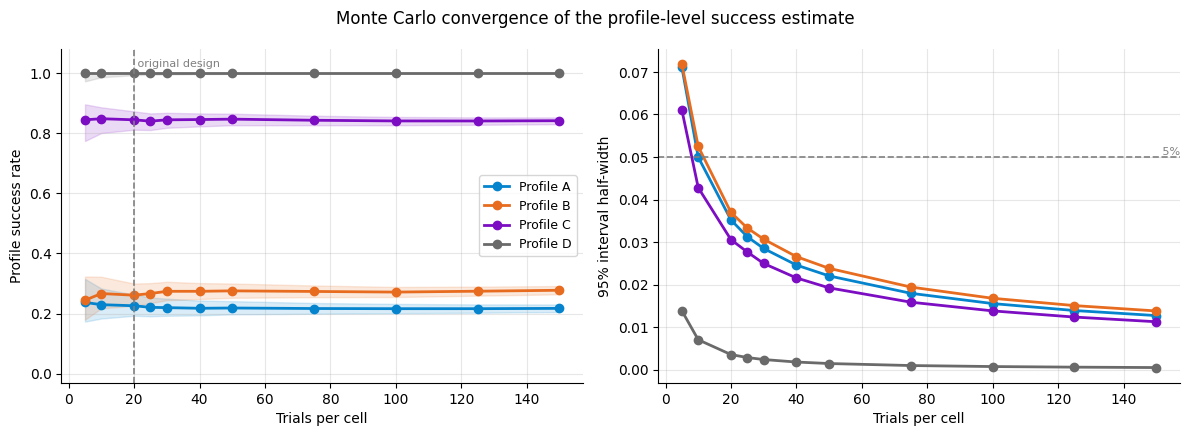

In [5]:
figure = plots.plot_convergence(exp1["convergence"], PROFILE_NAMES)
figure.show()

print("Convergence report (target half-width 0.05):")
for label, row in exp1["convergence_report"].items():
    if not label.startswith("profile"):
        continue
    print(f"  {label}: reached at n={row['n_for_target']} per cell, "
          f"final estimate {row['final_estimate']:.3f} "
          f"(half-width {row['final_half_width']:.3f}), "
          f"max drift after that point {row['max_drift_after_target']:.3f}")

print("\nWhat the original resolution would have shown, against the full run:")
for profile in PROFILE_NAMES:
    curve = exp1["convergence"][f"profile_{profile}"]
    early = min(curve, key=lambda point: abs(point["n"] - 20))
    final = curve[-1]
    print(f"  {profile}: {early['estimate']:.3f} +/- {early['half_width']:.3f} at n={early['n']}"
          f"  vs  {final['estimate']:.3f} +/- {final['half_width']:.3f} at n={final['n']}")

## Seed robustness

Each profile was run as five independent batches under different base seeds.

  A: batches ['0.220', '0.215', '0.216', '0.214', '0.222']  SD 0.0036  range 0.0086
  B: batches ['0.274', '0.268', '0.270', '0.280', '0.295']  SD 0.0108  range 0.0272
  C: batches ['0.844', '0.848', '0.823', '0.847', '0.844']  SD 0.0102  range 0.0247
  D: batches ['1.000', '1.000', '1.000', '1.000', '1.000']  SD 0.0000  range 0.0000

Between-batch SD across the 108 cells: median 0.000, max 0.143


/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74871/2252067887.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


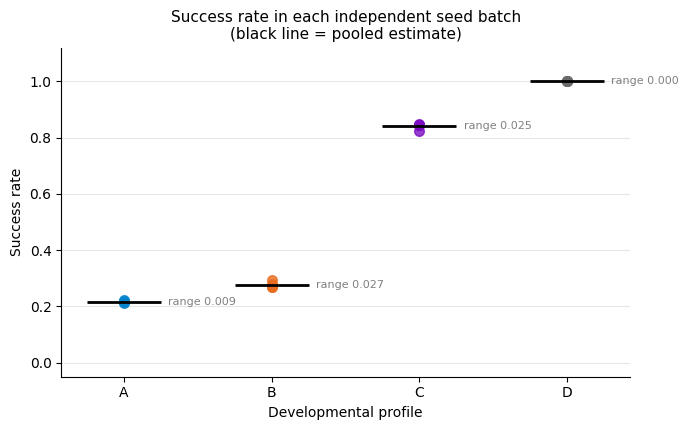

In [6]:
figure = plots.plot_seed_batches(profile_summary, PROFILE_NAMES)
figure.show()

for profile in PROFILE_NAMES:
    row = profile_summary[profile]
    rates = row["batch_success_rates"]
    print(f"  {profile}: batches {[f'{r:.3f}' for r in rates]}  "
          f"SD {row['between_batch_sd']:.4f}  range {row['between_batch_range']:.4f}")

cell_sds = [row["between_batch_sd"] for row in cell_summaries]
print(f"\nBetween-batch SD across the 108 cells: median {np.median(cell_sds):.3f}, "
      f"max {np.max(cell_sds):.3f}")

## Distribution of success across tasks

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74871/905256690.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_success_dotplot(cell_summaries, PROFILE_NAMES).show()
/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74871/905256690.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_task_heatmap(cell_summaries, PROFILE_NAMES, TASK_META).show()


Shape of each profile's distribution across the 27 tasks:
  A: 78% at floor, 11% at ceiling, 11% intermediate
  B: 37% at floor, 11% at ceiling, 52% intermediate
  C: 0% at floor, 67% at ceiling, 33% intermediate
  D: 0% at floor, 100% at ceiling, 0% intermediate


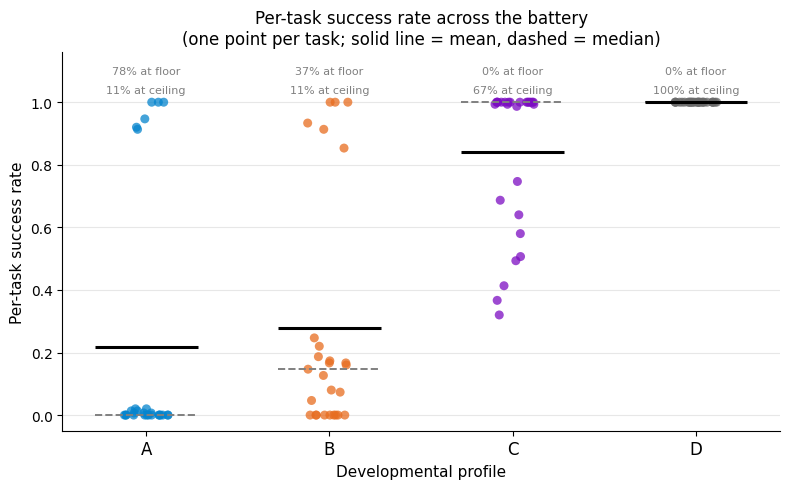

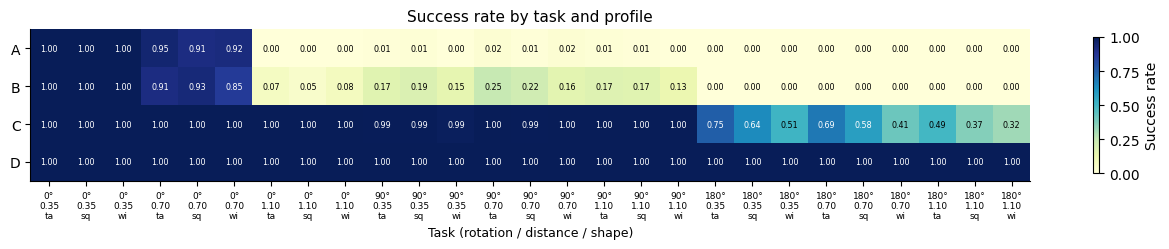

In [7]:
plots.plot_success_dotplot(cell_summaries, PROFILE_NAMES).show()
plots.plot_task_heatmap(cell_summaries, PROFILE_NAMES, TASK_META).show()

print("Shape of each profile's distribution across the 27 tasks:")
for profile in PROFILE_NAMES:
    values = np.array([row["success_rate"] for row in cell_summaries if row["stage"] == profile])
    print(f"  {profile}: {np.mean(values <= 0.05):.0%} at floor, "
          f"{np.mean(values >= 0.95):.0%} at ceiling, "
          f"{np.mean((values > 0.05) & (values < 0.95)):.0%} intermediate")

## Effect of each task dimension

The profile-by-demand interaction is quantified.
`demand_contrasts` gives the change in success from the easiest to the hardest
level of each factor, per profile, with an interval.

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74871/129299590.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_marginal_effects(exp1["marginals"], PROFILE_NAMES).show()



Change in success from easiest to hardest distance:
  A: 0.336 -> 0.002  change -0.333 [-0.359, -0.308]
  B: 0.389 -> 0.074  change -0.315 [-0.344, -0.285]
  C: 0.874 -> 0.798  change -0.076 [-0.104, -0.049]
  D: 1.000 -> 1.000  change +0.000 [+0.000, +0.000]

Change in success from easiest to hardest rotation:
  A: 0.642 -> 0.000  change -0.642 [-0.668, -0.617]
  B: 0.656 -> 0.000  change -0.656 [-0.681, -0.630]
  C: 1.000 -> 0.528  change -0.472 [-0.498, -0.445]
  D: 1.000 -> 1.000  change +0.000 [+0.000, +0.000]

Change in success from easiest to hardest aspect ratio:
  A: 0.221 -> 0.216  change -0.005 [-0.036, +0.026]
  B: 0.286 -> 0.263  change -0.023 [-0.057, +0.011]
  C: 0.880 -> 0.803  change -0.077 [-0.104, -0.050]
  D: 1.000 -> 1.000  change +0.000 [+0.000, +0.000]

Aspect ratio coded two ways (the design confounds elongation with its orientation):
  A: tall 0.221  square 0.216  wide 0.216
  B: tall 0.286  square 0.284  wide 0.263
  C: tall 0.880  square 0.841  wide 0.803
  

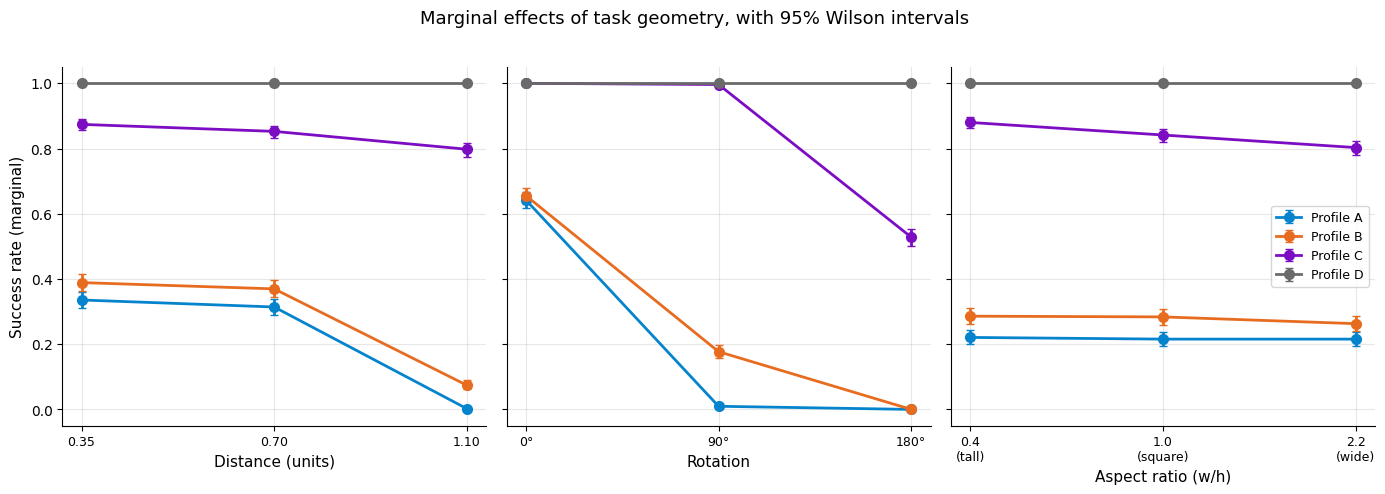

In [8]:
plots.plot_marginal_effects(exp1["marginals"], PROFILE_NAMES).show()

for factor, label in (("dist", "distance"), ("rot", "rotation"), ("aspect", "aspect ratio")):
    print(f"\nChange in success from easiest to hardest {label}:")
    for profile in PROFILE_NAMES:
        row = exp1["demand_contrasts"][factor][profile]
        print(f"  {profile}: {row['easiest']:.3f} -> {row['hardest']:.3f}  "
              f"change {row['change']:+.3f} [{row['ci_low']:+.3f}, {row['ci_high']:+.3f}]")

print("\nAspect ratio coded two ways (the design confounds elongation with its orientation):")
for profile in PROFILE_NAMES:
    shape = exp1["elongation"]["by_shape"][profile]
    print(f"  {profile}: " + "  ".join(
        f"{name} {shape[name]['success_rate']:.3f}" for name in ("tall", "square", "wide")))

## Failure

In [9]:
for profile in PROFILE_NAMES:
    row = exp1["failed_trajectories"][profile]
    if row["n_failed"] == 0:
        print(f"  {profile}: no failed trials")
        continue
    print(f"  {profile}: {row['n_failed']} failures | "
          f"start {row['mean_initial_pos_error']:.2f} -> peak {row['mean_peak_pos_error']:.2f} "
          f"-> end {row['mean_final_pos_error']:.2f} | "
          f"{row['prop_ending_further_than_start']:.0%} end further away than they started, "
          f"{row['prop_ending_beyond_twice_start']:.0%} beyond twice that distance, "
          f"{row['prop_final_within_5pct_of_peak']:.0%} never recover from their furthest point")

  A: 3170 failures | start 0.77 -> peak 3.16 -> end 3.09 | 100% end further away than they started, 100% beyond twice that distance, 85% never recover from their furthest point
  B: 2926 failures | start 0.77 -> peak 2.49 -> end 2.37 | 100% end further away than they started, 94% beyond twice that distance, 60% never recover from their furthest point
  C: 642 failures | start 0.78 -> peak 1.03 -> end 0.88 | 60% end further away than they started, 16% beyond twice that distance, 26% never recover from their furthest point
  D: no failed trials


## Design robustness

Whether the profile ordering and the shape of the success function survive the
success tolerance, the step-limit formula, and the treatment of object symmetry.

In [10]:
for name, comparison in (("Success tolerance", robustness["tolerance_comparison"]),
                         ("Step limit", robustness["steplimit_comparison"]),
                         ("Object symmetry", robustness["symmetry_comparison"])):
    print(f"\n{name}: ordering preserved = {comparison['ordering_preserved']}")
    designs = list(comparison["table"])
    print(f"  {'design':24s}" + "".join(f"{p:>9s}" for p in PROFILE_NAMES))
    for design in designs:
        print(f"  {design:24s}" + "".join(
            f"{comparison['table'][design][p]:9.3f}" for p in PROFILE_NAMES))
    print("  largest shift per profile: " + ", ".join(
        f"{p} {comparison['max_shift'][p]:.3f}" for p in PROFILE_NAMES))


Success tolerance: ordering preserved = True
  design                          A        B        C        D
  tolerance_strict            0.223    0.272    0.768    0.999
  tolerance_default           0.219    0.281    0.832    1.000
  tolerance_lenient           0.219    0.276    0.849    1.000
  largest shift per profile: A 0.005, B 0.009, C 0.081, D 0.001

Step limit: ordering preserved = True
  design                          A        B        C        D
  tolerance_default           0.219    0.281    0.832    1.000
  steplimit_short             0.219    0.272    0.751    0.992
  steplimit_long              0.221    0.281    0.856    1.000
  largest shift per profile: A 0.003, B 0.009, C 0.105, D 0.008

Object symmetry: ordering preserved = True
  design                          A        B        C        D
  tolerance_default           0.219    0.281    0.832    1.000
  symmetry_rectangle          0.221    0.278    0.812    0.999
  largest shift per profile: A 0.003, B 0.004, C 0

## Performance profile summary

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74871/3620919981.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_radar(profile_summary, PROFILE_NAMES).show()


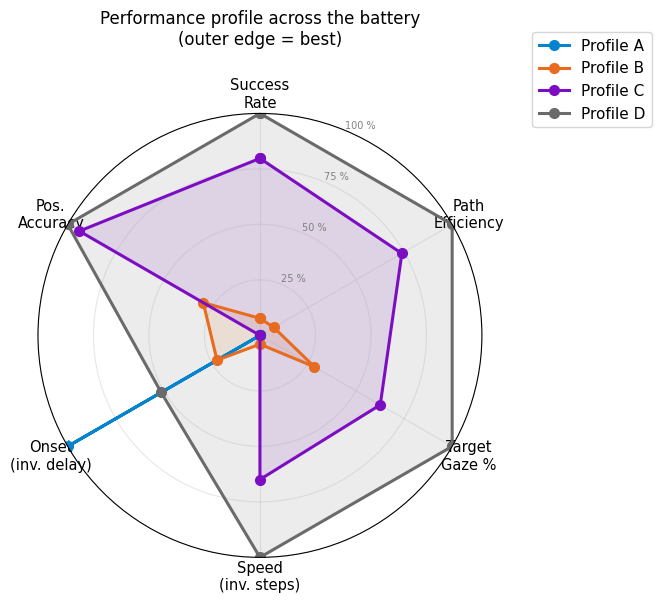

In [11]:
plots.plot_radar(profile_summary, PROFILE_NAMES).show()